In [3]:
!pip install git+https://github.com/mimoralea/gym-bandits#egg=gym-bandits
!pip install git+https://github.com/mimoralea/gym-walk#egg=gym-walk

  Cloning https://github.com/mimoralea/gym-bandits to /tmp/pip-install-0ou9rzql/gym-bandits_70f441cbba4a43b1b812efb906d452c2
  Running command git clone --filter=blob:none --quiet https://github.com/mimoralea/gym-bandits /tmp/pip-install-0ou9rzql/gym-bandits_70f441cbba4a43b1b812efb906d452c2
  Resolved https://github.com/mimoralea/gym-bandits to commit f4b45d39e59eee3f6377ceb42466749af2cd77bd
  Preparing metadata (setup.py) ... done
  Created wheel for gym-bandits: filename=gym_bandits-0.1-py3-none-any.whl size=5228 sha256=67a1e78261db9371c1a0b901cbe41e0faa117e5ca8bc4d1915439151b03a822b
  Stored in directory: /tmp/pip-ephem-wheel-cache-39d0wiw7/wheels/e3/80/17/2f221a51a2b9f310bc08097546d94bbcbc646f9374f25da82a
Successfully built gym-bandits
  Cloning https://github.com/mimoralea/gym-walk to /tmp/pip-install-3sy6zj24/gym-walk_56475ed36eca413baef9e726c571a65c
  Running command git clone --filter=blob:none --quiet https://github.com/mimoralea/gym-walk /tmp/pip-install-3sy6zj24/gym-walk_564

In [23]:
import numpy as np
import gymnasium as gym

import warnings ; warnings.filterwarnings('ignore')

from pprint import pprint
# from tqdm import tqdm_notebook as tqdm
from tqdm.notebook import tqdm

from itertools import cycle

import random

np.set_printoptions(suppress=True)
random.seed(123); np.random.seed(123)
SEEDS = (12, 34, 56, 78, 90)



In [24]:
import gym_bandits
import gym
env = gym.make("BanditTenArmedGaussian-v0")
env.reset()

0

  0%|          | 0/100000 [00:00<?, ?it/s]

(array([    2.,     6.,    40.,   234.,   710.,  2082.,  4684.,  8841.,
        13891., 17434., 17674., 14897., 10133.,  5545.,  2547.,   919.,
          286.,    58.,    15.,     2.]),
 array([-4.27216515, -3.81558272, -3.35900029, -2.90241786, -2.44583543,
        -1.98925301, -1.53267058, -1.07608815, -0.61950572, -0.1629233 ,
         0.29365913,  0.75024156,  1.20682399,  1.66340642,  2.11998884,
         2.57657127,  3.0331537 ,  3.48973613,  3.94631855,  4.40290098,
         4.85948341]),
 <BarContainer object of 20 artists>)

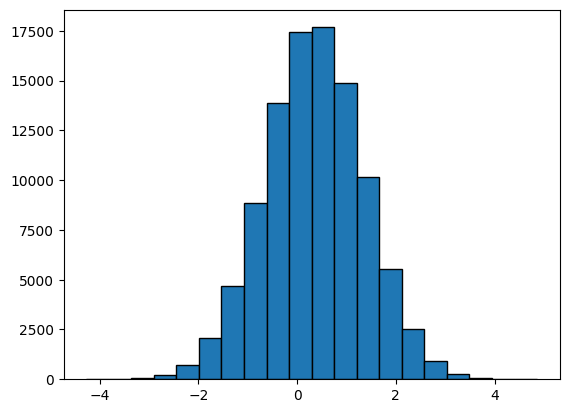

In [26]:
Q = np.zeros((env.action_space.n))
action = np.argmax(Q)

_, reward, _ , _ = env.step(action)
rewards=[]
for i in tqdm( range (100000)):
  _, reward, _ , _ = env.step(action)
  rewards.append(reward)

## distribution of rewards for many iterations

import matplotlib.pyplot as plt

plt.hist(rewards, edgecolor='black', bins=20)

In [27]:
print(env.env.r_dist)
print(env.env.p_dist)

[[0.345584192064786, 1], [0.8216181435011584, 1], [0.33043707618338714, 1], [-1.303157231604361, 1], [0.9053558666731177, 1], [0.4463745723640113, 1], [-0.5369532353602852, 1], [0.5811181041963531, 1], [0.36457239618607573, 1], [0.294132496655526, 1]]
[1 1 1 1 1 1 1 1 1 1]


In [28]:
b10_Vs = []
for seed in SEEDS:
    env_name = 'BanditTenArmedGaussian-v0'
    env = gym.make(env_name, seed=seed) ; env.reset()
    r_dist = np.array(env.env.r_dist)[:,0]
    b10_Q = np.array(env.env.p_dist * r_dist)

    print('10-Armed Bandit environment with seed', seed)
    ## reward always pays out --> so prob of getting reward is always 1
    print('Probability of reward:', env.env.p_dist)
    ## reward values will change as per the seed
    print('Reward:', r_dist)

    print('Q(.):', b10_Q)

    b10_Vs.append(np.max(b10_Q))

    print('V*:', b10_Vs[-1])

    print()
print('Mean V* across all seeds:', np.mean(b10_Vs))

10-Armed Bandit environment with seed 12
Probability of reward: [1 1 1 1 1 1 1 1 1 1]
Reward: [-0.00682678  1.04614329  0.74158842  0.72395654  1.61877622 -1.20555814
 -0.62695547 -1.32066321 -0.10775251  0.99876366]
Q(.): [-0.00682678  1.04614329  0.74158842  0.72395654  1.61877622 -1.20555814
 -0.62695547 -1.32066321 -0.10775251  0.99876366]
V*: 1.6187762233340763

10-Armed Bandit environment with seed 34
Probability of reward: [1 1 1 1 1 1 1 1 1 1]
Reward: [-0.03992466 -1.25773672  2.57402319  0.48179798  0.64354662 -0.20792668
  0.05828708  0.33674264  0.19510709 -0.60931449]
Q(.): [-0.03992466 -1.25773672  2.57402319  0.48179798  0.64354662 -0.20792668
  0.05828708  0.33674264  0.19510709 -0.60931449]
V*: 2.574023189963745

10-Armed Bandit environment with seed 56
Probability of reward: [1 1 1 1 1 1 1 1 1 1]
Reward: [-0.84994072  0.32194085  1.78904286  0.8793392   0.37159282  1.48769378
  0.72866553  2.08124873 -1.33726808  0.12535155]
Q(.): [-0.84994072  0.32194085  1.78904286  

## Pure exploitation


In [12]:
def bandit_pure_exploit(env, n_episodes=5000):
  Q =np.zeros((env.action_space.n))
  N =np.zeros((env.action_space.n))

  ## storing estimates for each episodes
  Qe = np.empty((n_episodes, env.action_space.n))
  returns = np.empty(n_episodes)
  actions = np.empty(n_episodes, dtype=int)

  name = 'pure_exploitation'
  for e in tqdm(range(n_episodes), desc = "Episodes for : "+name, leave = False):
    ## always select the action with highest current Q-value-- this is where the exploitation is happening
    action = np.argmax(Q)
    ## taking the action we are getting some reward
    _, reward, _ , _ = env.step(action)
    ## count
    N[action] +=1
    ## updating the Q table
    Q[action] = Q[action] +(reward - Q[action])/N[action]

    ## storing data in the Final tables
    Qe[e] = Q
    returns[e] =reward
    actions[e] = action

  return name, returns, Qe, actions

In [14]:
name, returns, Qe, actions= bandit_pure_exploit(env)

Episodes for : pure_exploitation:   0%|          | 0/5000 [00:00<?, ?it/s]

In [15]:
print("Qe shape",Qe.shape)
print()
print(Qe[55])
print(Qe[550])
print(Qe[54,0])

Qe shape (5000, 10)

[1.75742349 0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]
[1.80006498 0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]
1.7564254390341671


(array([   7.,   60.,  341.,  818., 1368., 1302.,  781.,  263.,   55.,
           5.]),
 array([-1.8319388 , -1.09251205, -0.3530853 ,  0.38634145,  1.1257682 ,
         1.86519495,  2.6046217 ,  3.34404845,  4.0834752 ,  4.82290195,
         5.5623287 ]),
 <BarContainer object of 10 artists>)

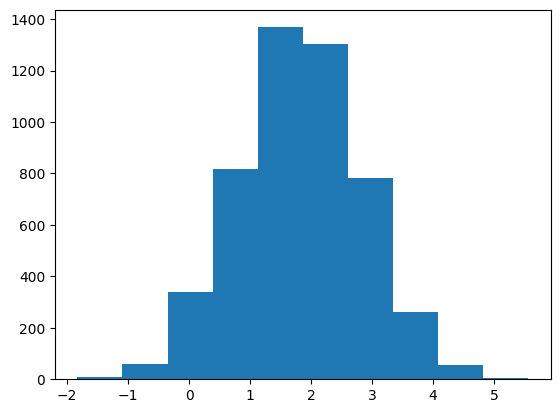

In [ ]:
plt.hist(returns)

(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   2.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   2.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,
          3.,   1.,   2.,   1.,   1.,   1.,   0.,   2.,   5.,   0.,   3.,
          2.,   3.,  20.,  38.,  17.,   7.,  12.,  98., 417., 266., 161.,
        878., 750., 503., 263., 221., 185., 286., 256., 193., 103.,  67.,
         46.,   1.,   7.,   8.,  12.,  16.,   7.,  16.,  10.,  12.,   8.,
          5.,  10.,   3.,   7.,   5.,   3.,   2.,   6.,   7.,   5.,   4.,
          7.,   4.,   4.,   2.,   0., 

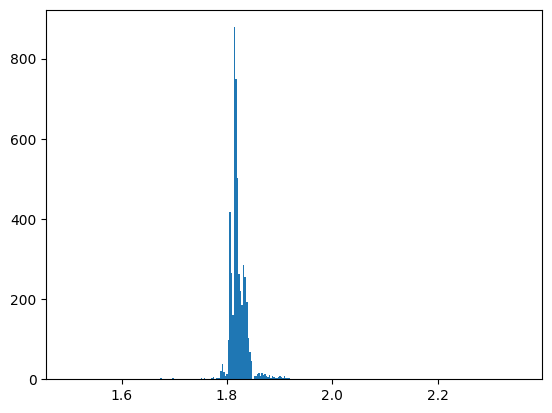

In [16]:
plt.hist(Qe[:,0], bins=300)

## Pure Exoploration

In [33]:
def pure_explore(env, n_episodes=5000):
  Q =np.zeros((env.action_space.n))
  N =np.zeros((env.action_space.n))

  ## storing estimates for each episodes
  Qe = np.empty((n_episodes, env.action_space.n))
  returns = np.empty(n_episodes)
  actions = np.empty(n_episodes, dtype=int)

  name ='pure exploration'
  for e in tqdm(range(n_episodes), desc = 'Episodes for: '+name, leave=False):
    action = np.random.randint(len(Q))
    _, reward, _ , _ = env.step(action)
    ## count
    N[action] +=1
    ## updating the Q table
    Q[action] = Q[action] +(reward - Q[action])/N[action]

    ## storing data in the Final tables
    Qe[e] = Q
    returns[e] =reward
    actions[e] = action

  return name, returns, Qe, actions


In [35]:
name, returns, Qe, actions = pure_explore(env)

Episodes for: pure exploration:   0%|          | 0/5000 [00:00<?, ?it/s]

Qe shape (5000, 10)

55  [ 1.8570927  -0.30629976 -0.20179174  1.62253079 -0.57765966  0.40924231
  1.97508951  1.08529657  1.50914791  0.52559288]
550  [ 1.72449859 -0.48589949  0.10888563  0.56346647 -0.42304445  0.01354782
  1.68785607  1.21816492  0.85363908  0.2742063 ]
54  [ 1.8570927  -0.28445206 -0.20179174  1.62253079 -0.57765966  0.40924231
  1.97508951  1.08529657  1.50914791  0.52559288]


(array([  14.,  108.,  432.,  984., 1255., 1073.,  703.,  323.,   90.,
          18.]),
 array([-3.49205171, -2.66707923, -1.84210676, -1.01713429, -0.19216182,
         0.63281066,  1.45778313,  2.2827556 ,  3.10772807,  3.93270055,
         4.75767302]),
 <BarContainer object of 10 artists>)

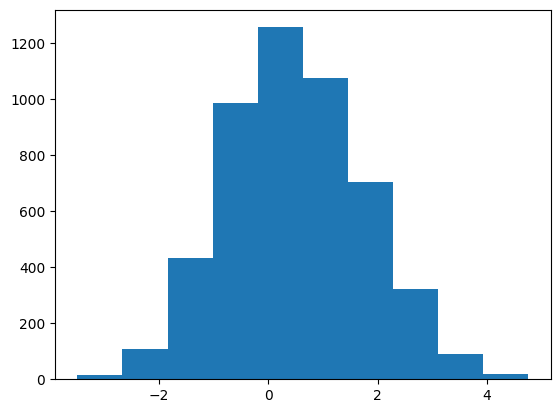

In [42]:
print("Qe shape",Qe.shape)
print()
print("55 ",Qe[55])
print("550 ",Qe[550])
print("54 ",Qe[54])
print("=========================")
plt.hist(returns)